This script has been developed using the google collab notebook and data was stored and loaded from google drive.

### Model development and training

In [1]:
#@title Import libraries and dataset
import os
import torch
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, random_split
from torchvision import models
from torch import optim
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
#@title Define neural network, __init__ and forward functions
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)  #although it is not mandatory to halve the image size, but it helps to reduce the computation time and overfitting
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [3]:
#@title Instantiate the Model
net = Net()

# define the Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [4]:
#Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#Choosing a location in the drive
project_path= "/content/drive/MyDrive/Colab Notebooks/deep_learning"
dataset_path =os.path.join(project_path,"datasets")

In [6]:
#@title Load and transform the data
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Load the original training set (50,000 images)
cifar_trainset = CIFAR10(root=dataset_path, train=True,
                                        download=True, transform=transform)

# Split into training (40,000) and validation (10,000)
generator = torch.Generator().manual_seed(42) #fix the split

trainset, valset = random_split(cifar_trainset, [40000, 10000], generator= generator)

#Load the training set
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)
#Load the validation set
valloader = torch.utils.data.DataLoader(valset,
                                        batch_size=4,
                                        shuffle=False,
                                        num_workers=2)
#Load the test set
testset = CIFAR10(root=dataset_path, train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

In [17]:
#@title Train the network

best_val_accuracy = 0.0

for epoch in range(10):  # loop over the dataset multiple times
    running_loss = 0.0

    # For training accuracy
    correct = 0
    total = 0

    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a tuple of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 2000 == 1999:  # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    # Calculate training accuracy after each epoch
    train_accuracy = 100 * correct / total
    print(f'Epoch {epoch + 1}: Training Accuracy = {train_accuracy:.2f}%')

    # Calculate validation accuracy
    correct = 0
    total = 0

    with torch.no_grad():
        for data in valloader:
            images, labels = data
            outputs = net(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    validation_accuracy = 100 * correct / total
    print(f'Epoch {epoch + 1}: Validation Accuracy = {validation_accuracy:.2f}%')

    # Save the model if validation accuracy improves
    if validation_accuracy > best_val_accuracy:
        best_val_accuracy = validation_accuracy
        model_path = os.path.join(project_path, "best_model.pth")
        torch.save(net.state_dict(), model_path) #save the model
        print(f'Best model with validation accuracy: {best_val_accuracy:.2f}%')

print('Finished Training')

[1,  2000] loss: 2.180
[1,  4000] loss: 1.842
[1,  6000] loss: 1.674
[1,  8000] loss: 1.587
[1, 10000] loss: 1.538
Epoch 1: Training Accuracy = 34.88%
Epoch 1: Validation Accuracy = 45.75%
Best model with validation accuracy: 45.75%
[2,  2000] loss: 1.459
[2,  4000] loss: 1.421
[2,  6000] loss: 1.387
[2,  8000] loss: 1.382
[2, 10000] loss: 1.344
Epoch 2: Training Accuracy = 49.57%
Epoch 2: Validation Accuracy = 51.68%
Best model with validation accuracy: 51.68%
[3,  2000] loss: 1.276
[3,  4000] loss: 1.242
[3,  6000] loss: 1.244
[3,  8000] loss: 1.244
[3, 10000] loss: 1.224
Epoch 3: Training Accuracy = 55.66%
Epoch 3: Validation Accuracy = 55.33%
Best model with validation accuracy: 55.33%
[4,  2000] loss: 1.158
[4,  4000] loss: 1.152
[4,  6000] loss: 1.152
[4,  8000] loss: 1.143
[4, 10000] loss: 1.154
Epoch 4: Training Accuracy = 59.14%
Epoch 4: Validation Accuracy = 57.26%
Best model with validation accuracy: 57.26%
[5,  2000] loss: 1.061
[5,  4000] loss: 1.058
[5,  6000] loss: 1.091

Best validation with 60.99% accuracy at Epoch 9. This is a reasonable baseline.


**Model Evaluation on Testset**

In [7]:
net = Net() #create the model with the same net architecture

model_path = os.path.join(project_path, "best_model.pth") #define the path
net.load_state_dict(torch.load(model_path)) #load the best model from where it is saved

net.eval()  #put the model on the evaluation mode

print("Best model loaded successfully!!")

Best model loaded successfully!!


In [8]:
# Evaluate the model on the test set

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        outputs = net(images) #predicting the images

        _, predicted = torch.max(outputs.data, 1) #determining the predicted class

        total += labels.size(0)
        correct += (predicted == labels).sum().item() #measuring the accurately predicted image numbers

test_accuracy = 100 * correct / total #calculating the % of accuracy against total test set
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 61.08%


So, 61.08% as the baseline test accuracy.

**Confusion Matrix**

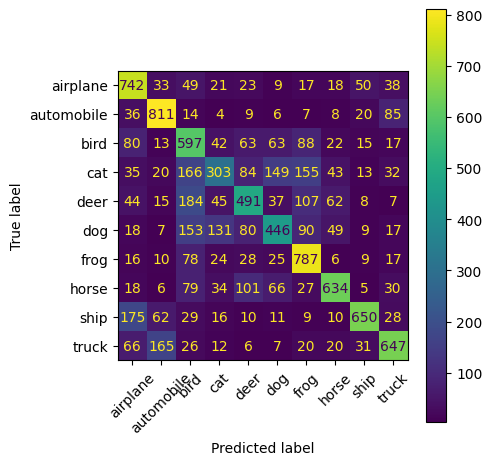

In [12]:

#Get the class names
classes= testset.classes
#classes

# Store true labels and predictions
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in testloader:
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, xticks_rotation=45)

#plt.title("CIFAR-10 Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(project_path, "confusion_matrix.png"))
plt.show()


Next step would be to improve the CNN.